In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def read_regenie(filepath):
    """Чтение файла REGENIE, восстановление P и -log10(P)."""
    df = pd.read_csv(filepath, sep='\s+')
    if 'LOG10P' in df.columns:
        df['P'] = np.power(10, -df['LOG10P'])
    elif 'PVAL' in df.columns:
        df['P'] = df['PVAL']
    elif 'CHISQ' in df.columns:
        df['P'] = chi2.sf(df['CHISQ'], 1)
    else:
        raise ValueError("Нужны столбцы LOG10P, PVAL или CHISQ.")
    df['LOGP'] = -np.log10(df['P'])
    return df

def manhattan_plot_multi(df, title="Manhattan Plot", 
                         genomewide=-np.log10(5e-8), 
                         suggestive=-np.log10(1e-5),
                         color_list=['#1f77b4', '#ff7f0e']):
    """
    Manhattan plot для любого количества хромосом.
    df должен содержать столбцы: CHROM (int/str), GENPOS (int), LOGP (float)
    """
    # Сортируем по хромосоме и позиции
    df = df.sort_values(['CHROM', 'GENPOS']).reset_index(drop=True)
    
    # Уникальные хромосомы в порядке появления
    chroms = df['CHROM'].unique()
    
    # Строим непрерывную координату
    df['CUM_POS'] = 0
    chrom_centers = []
    offset = 0
    for chrom in chroms:
        mask = df['CHROM'] == chrom
        if mask.sum() == 0:
            continue
        # Добавляем смещение к позициям этой хромосомы
        df.loc[mask, 'CUM_POS'] = df.loc[mask, 'GENPOS'] + offset
        # Запоминаем центр хромосомы (среднее арифметическое мин и макс позиций)
        chrom_min = df.loc[mask, 'CUM_POS'].min()
        chrom_max = df.loc[mask, 'CUM_POS'].max()
        chrom_centers.append((chrom_min + chrom_max) / 2)
        # Следующее смещение = текущий максимум + небольшой зазор (для красоты)
        offset = chrom_max + 1_000_000   # зазор 1 Мб, можно регулировать
    
    # Рисуем
    plt.figure(figsize=(16, 6))
    for i, chrom in enumerate(chroms):
        mask = df['CHROM'] == chrom
        color = color_list[i % len(color_list)]
        plt.scatter(df.loc[mask, 'CUM_POS'], df.loc[mask, 'LOGP'], 
                    color=color, s=4, label=f'Chr {chrom}' if i == 0 else "")
    
    # Горизонтальные линии значимости
    if genomewide:
        plt.axhline(y=genomewide, color='red', linestyle='-', linewidth=1, 
                    label='Genome-wide (5e-8)')
    if suggestive:
        plt.axhline(y=suggestive, color='blue', linestyle='--', linewidth=1, 
                    label='Suggestive (1e-5)')
    
    # Подписи хромосом по центру
    plt.xticks(chrom_centers, [str(c) for c in chroms], rotation=0)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p)")
    plt.title(title)
    
    # Легенда: показываем только линии значимости, убираем дублирующиеся метки хромосом
    handles, labels = plt.gca().get_legend_handles_labels()
    # Оставляем уникальные подписи (для хромосом оставляем только один label)
    unique = {}
    for handle, label in zip(handles, labels):
        if label not in unique and label != "Chr 1":
            unique[label] = handle
    plt.legend(unique.values(), unique.keys(), loc = "upper right", frameon=True, framealpha=None)
    plt.tight_layout()
    return plt.gcf()

In [18]:
from scipy.stats import beta
import numpy as np
def qq_plot(df, title="QQ Plot", ci=0.95):
    """
    QQ-plot для p-value из результатов GWAS.
    df должен содержать столбец 'P' (p-value).
    """
    pvals = df['P'].dropna().values
    pvals[pvals == 0] = np.finfo(float).tiny   # заменяем нули на минимальное float
    n = len(pvals)

    observed = -np.log10(np.sort(pvals))
    expected = -np.log10((np.arange(1, n+1) - 0.5) / n)

    # 95% доверительный интервал
    alpha = 1 - ci
    lower = -np.log10(beta.ppf(alpha/2, np.arange(1, n+1), n - np.arange(1, n+1) + 1))
    upper = -np.log10(beta.ppf(1 - alpha/2, np.arange(1, n+1), n - np.arange(1, n+1) + 1))

    # Коэффициент инфляции λ
    # λ = median(observed χ²) / 0.456 (для 1 df)
    chisq = chi2.isf(pvals, 1)
    lambda_gc = np.median(chisq) / chi2.ppf(0.5, 1)

    plt.figure(figsize=(6, 6))
    plt.fill_between(expected, lower, upper, color='gray', alpha=0.2, label=f'{int(ci*100)}% CI')
    plt.scatter(expected, observed, s=4, color='black', alpha=0.6)
    max_val = max(expected.max(), observed.max()) * 1.05
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='y = x')

    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    plt.title(title)
    plt.legend(loc='upper left', frameon=False)

    # Добавляем λ на график
    plt.text(0.05, 0.80, f'λ = {lambda_gc:.3f}', transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    return plt.gcf()

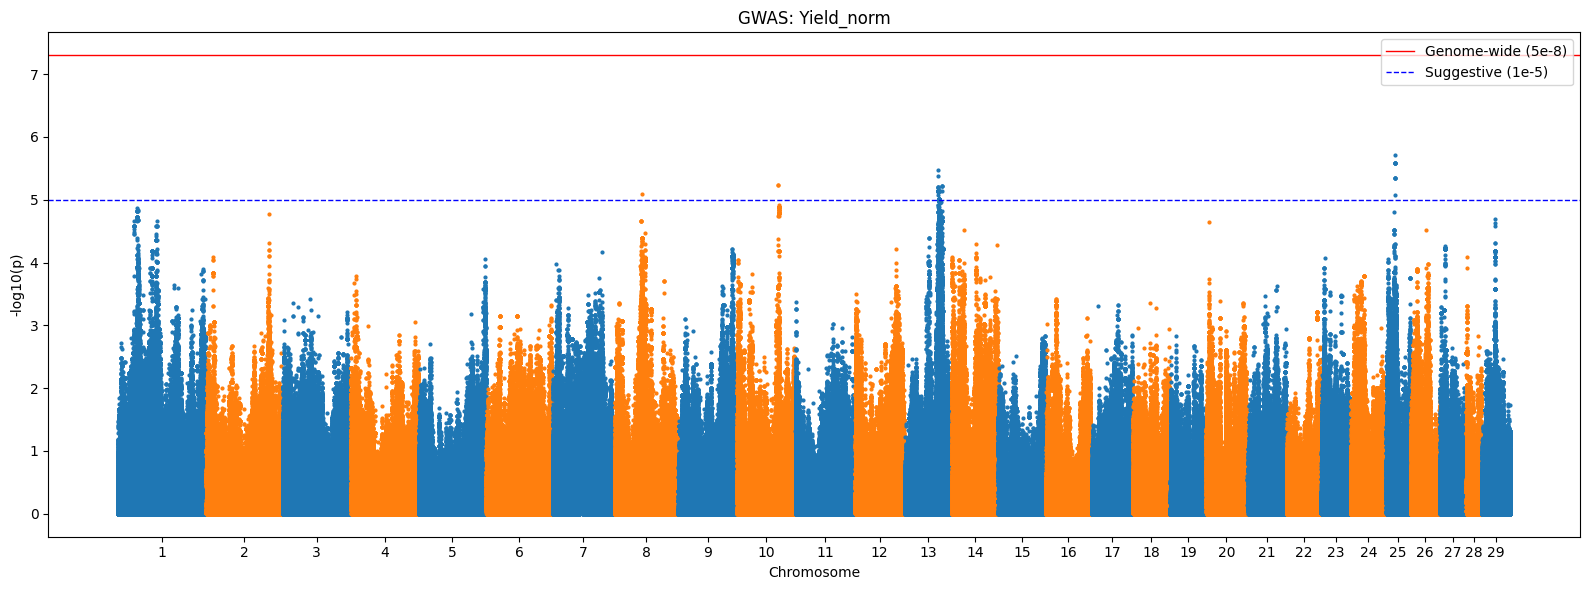

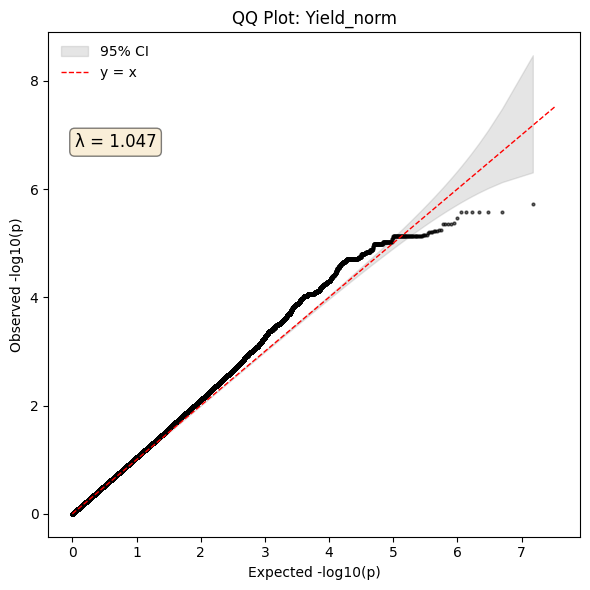

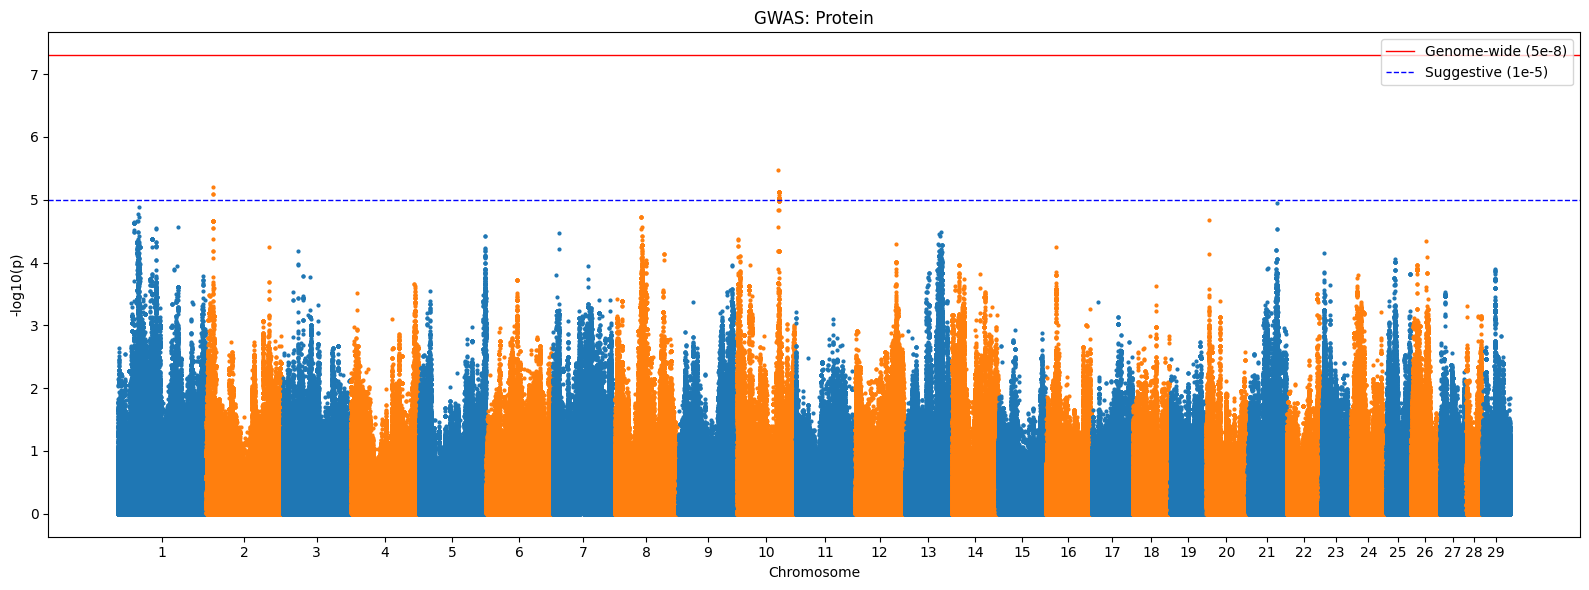

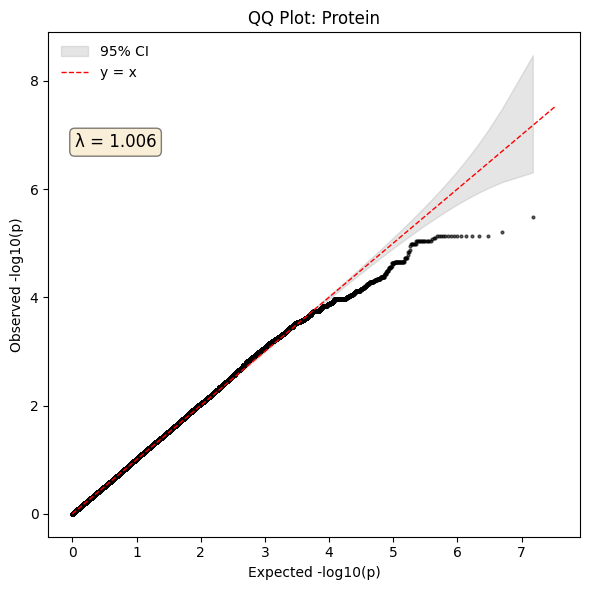

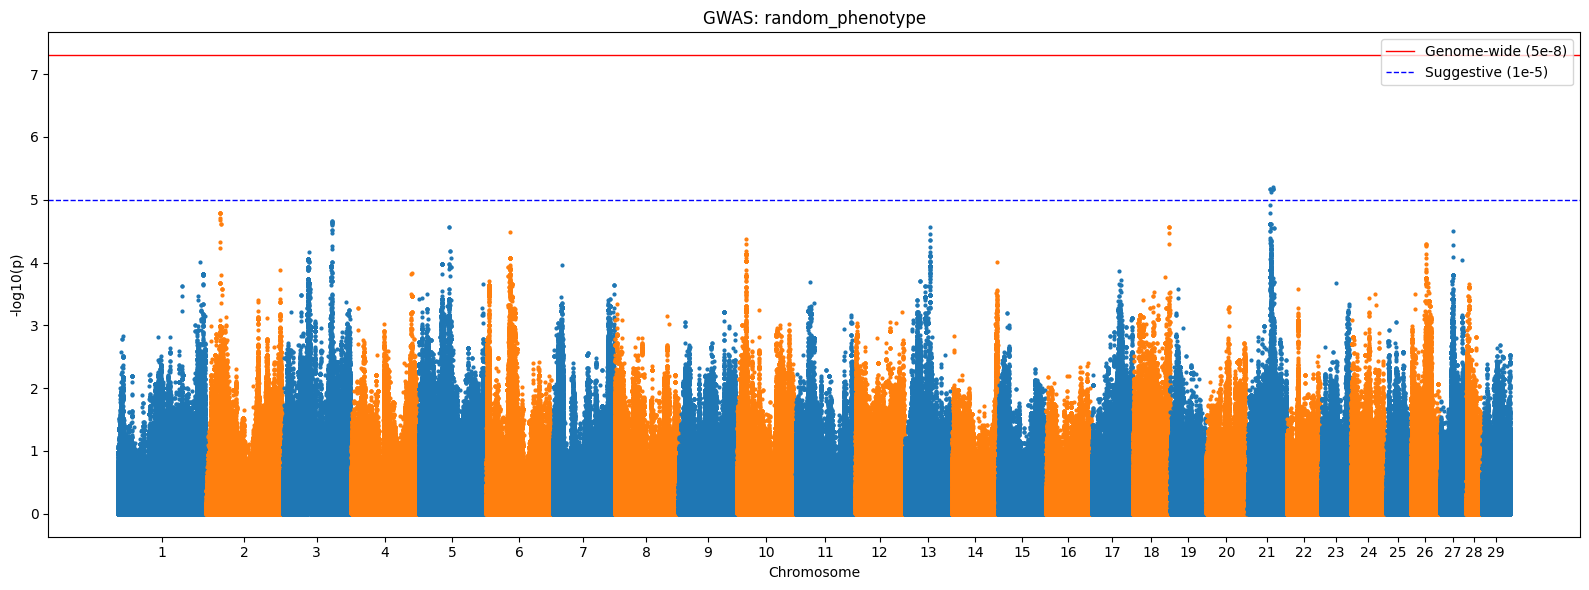

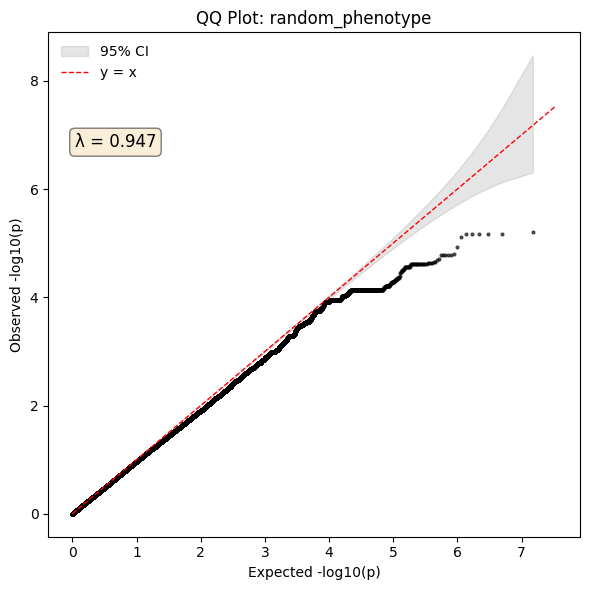

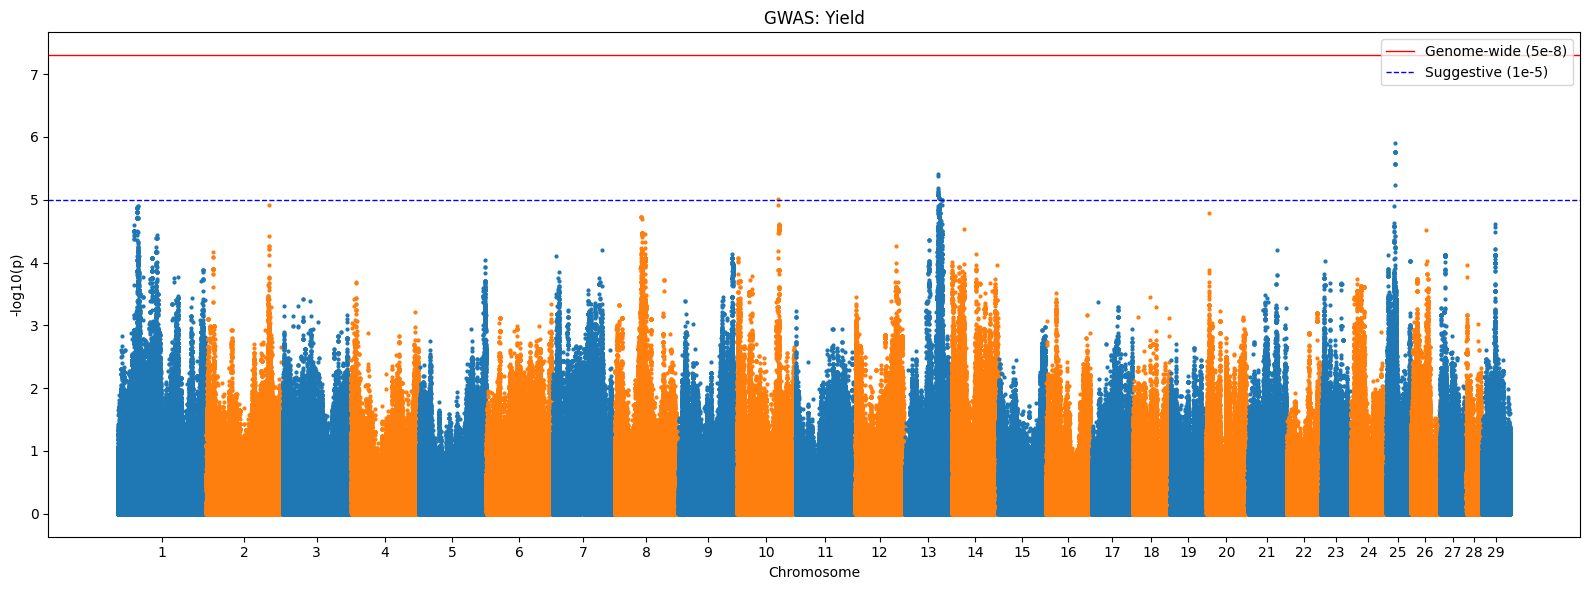

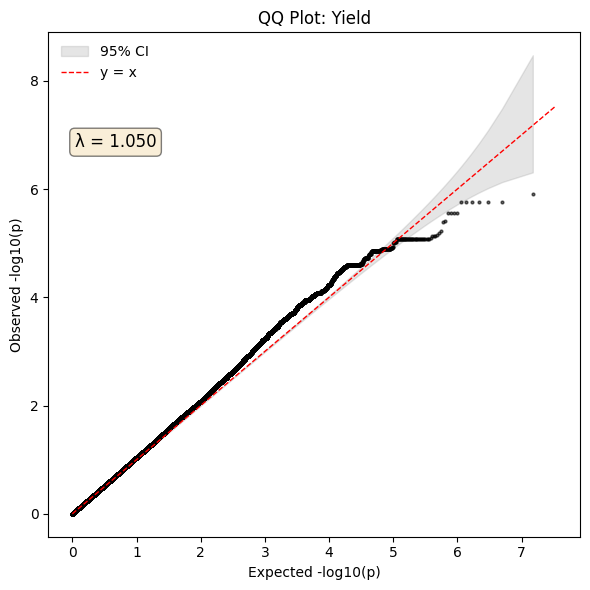

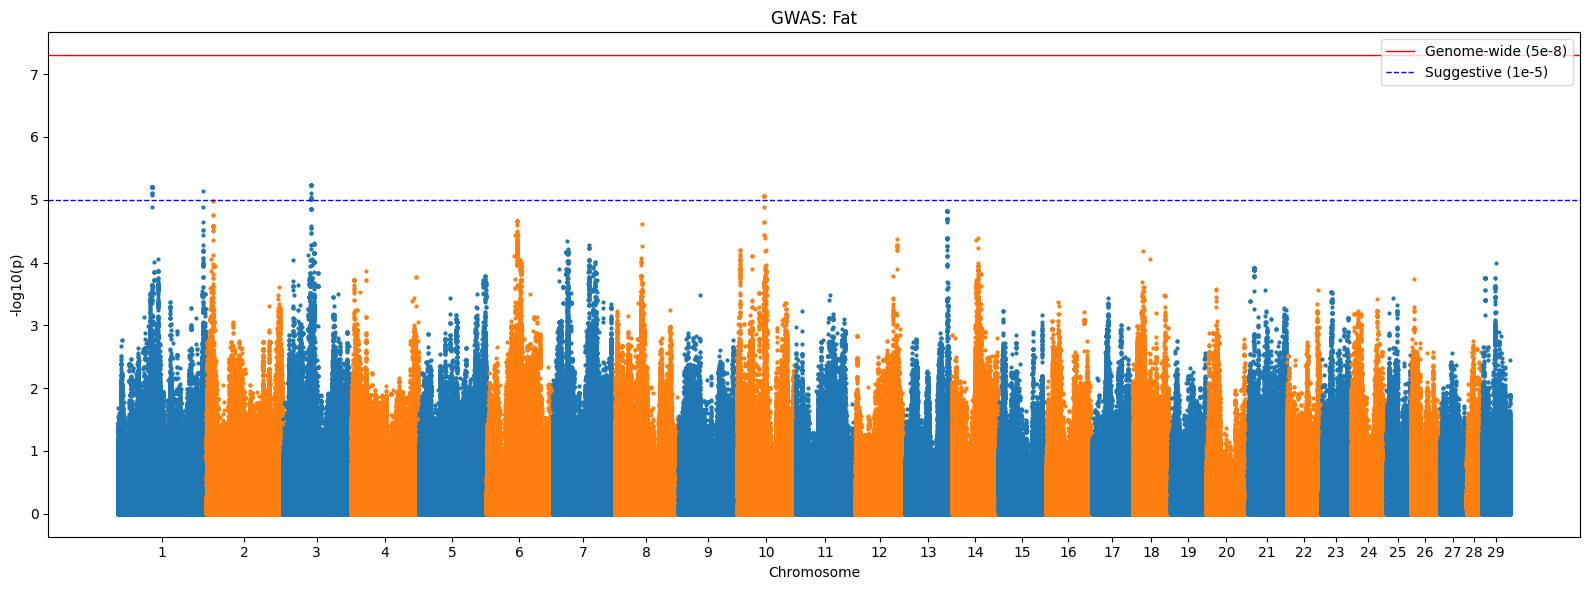

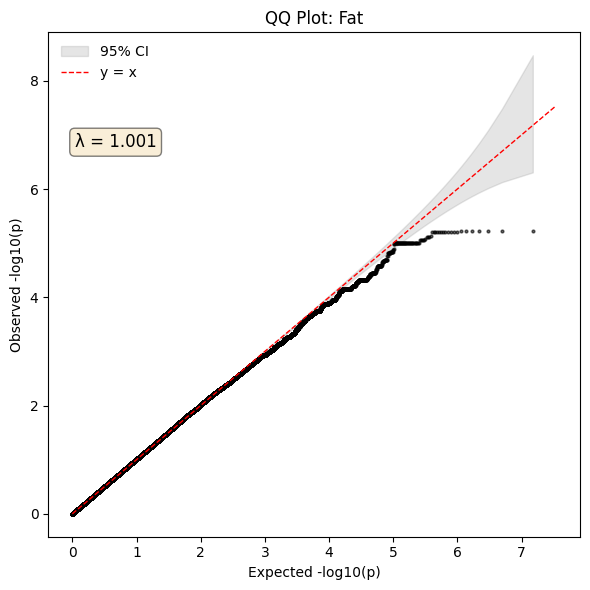

In [19]:
from pathlib import Path
all_phenotype_file = [file for file in Path("/scratch/storageA/zaleski_bulls/bulls-vcf-pipeline/results/gwas").iterdir() if file.is_file() and file.suffix == ".regenie"]

for path_gwas in all_phenotype_file:
    path_gwas = str(path_gwas)
    df_all = read_regenie(path_gwas)

    phenotype = path_gwas.split("/")[-1].removeprefix("final_gwas_results_").removesuffix(".regenie")
    # Manhattan
    fig_man = manhattan_plot_multi(df_all, title=f"GWAS: {phenotype}")
    # fig_man.savefig("manhattan_yield.png", dpi=150)

    # QQ-plot (тот же df, все хромосомы)
    fig_qq = qq_plot(df_all, title=f"QQ Plot: {phenotype}")
    # fig_qq.savefig("qq_yield.png", dpi=150)

plt.show()

In [20]:
# Порог suggestive
suggestive_threshold = 1e-5

# Отбираем SNP, где P < порога
sig_df = df_all[df_all['P'] < suggestive_threshold].copy()

# Сортируем по P-value (от самых значимых к менее значимым)
sig_df = sig_df.sort_values('P')

# Смотрим, сколько получилось
print(f"Найдено {len(sig_df)} suggestive SNP (p < 1e-5)")

Найдено 71 suggestive SNP (p < 1e-5)


In [21]:
sig_df

,CHROM,GENPOS,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,P,LOGP
1012323,3,49550821,3_49550821_G_C,G,C,0.136364,429,ADD,23.7557,5.24336,20.5265,5.23054,NaN,0.000006,5.23054
1012347,3,49553654,3_49553654_T_G,T,G,0.136364,429,ADD,23.7557,5.24336,20.5265,5.23054,NaN,0.000006,5.23054
1012149,3,49519105,3_49519105_C_G,C,G,0.136364,429,ADD,23.7557,5.24336,20.5265,5.23054,NaN,0.000006,5.23054
1012447,3,49564971,3_49564971_C_G,C,G,0.136364,429,ADD,23.7557,5.24336,20.5265,5.23054,NaN,0.000006,5.23054
1012672,3,49629934,3_49629934_A_G,A,G,0.136364,429,ADD,23.7557,5.24336,20.5265,5.23054,NaN,0.000006,5.23054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012614,3,49605591,3_49605591_A_G,A,G,0.137529,429,ADD,23.0659,5.21790,19.5410,5.00673,NaN,0.000010,5.00673
1012588,3,49592226,3_49592226_C_T,C,T,0.137529,429,ADD,23.0659,5.21790,19.5410,5.00673,NaN,0.000010,5.00673
1012707,3,49648999,3_49648999_G_A,G,A,0.137529,429,ADD,23.0659,5.21790,19.5410,5.00673,NaN,0.000010,5.00673
1012699,3,49644018,3_49644018_C_T,C,T,0.137529,429,ADD,23.0659,5.21790,19.5410,5.00673,NaN,0.000010,5.00673
